In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [12]:
df=pd.read_csv('Weather_data.csv',parse_dates=['Date'],index_col='Date')  # converting date into date-time format and setting as index

In [13]:
df.head()

,Temperature
Date,
2017-01-01,15.913043
2017-01-02,18.500000
2017-01-03,17.111111
2017-01-04,18.700000
2017-01-05,18.388889


In [14]:
df['Temperature']=df['Temperature'].interpolate()   # Interpolating missing values

In [15]:
result=adfuller(df['Temperature'])    # Stationarity Test
print(f"ADF Statistic={result[0]:.3f}, p-value={result[1]:.3f}")

ADF Statistic=-1.096, p-value=0.716


In [16]:
# f-strings make it easy to embed variables and expressions directly inside strings using curly braces {}.

In [17]:
# Since the p-value is greater than 0.05, the data is non-stationary, so we have to do differencing

In [18]:
df1=df['Temperature'].diff().dropna()

In [19]:
df1.head()

Date
2017-01-02    2.586957
2017-01-03   -1.388889
2017-01-04    1.588889
2017-01-05   -0.311111
2017-01-06    0.929293
Name: Temperature, dtype: float64

In [20]:
# plot ACF and PACF plots

In [ ]:
# A subplot is a plot inside a larger figure — useful when you want to display multiple plots side by side or stacked vertically/horizontally.

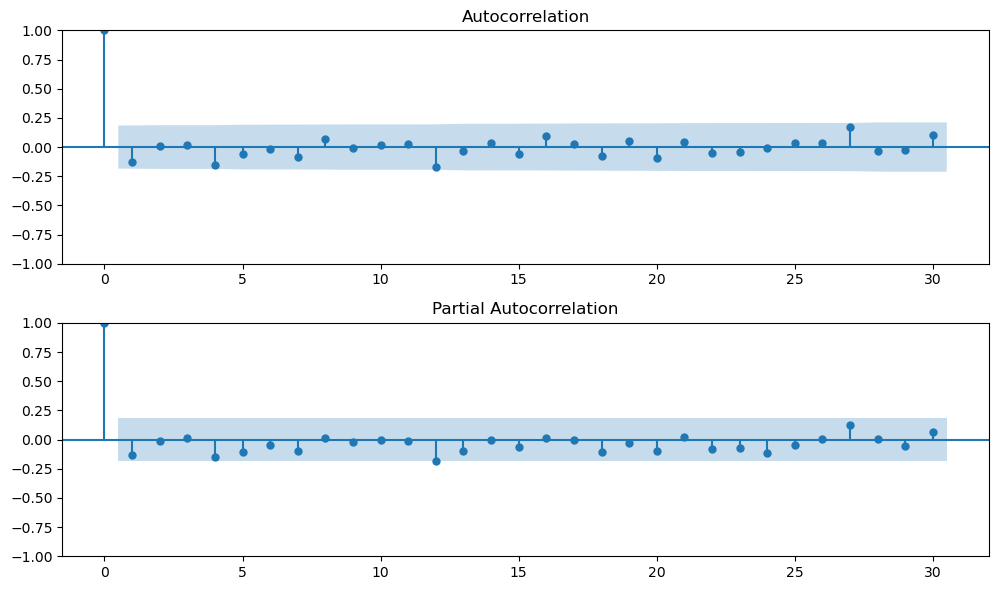

In [21]:
fig,ax=plt.subplots(2,1,figsize=(10,6))    # subplot with 2 rows and 1 column, and width=10, and height=6 inches
plot_acf(df1, lags=30,ax=ax[0])             # ax is numpy array of plots
plot_pacf(df1,lags=30,ax=ax[1])

plt.tight_layout()   ## plt.tight_layout() is a Matplotlib function used to automatically adjust the spacing between subplots so that they don't overlap.
plt.show()

In [23]:
# Train_test_split

In [24]:
train_size=int(len(df1)*0.8)

train=df1[:train_size]
test=df1[train_size:]

In [25]:
# Model fitting

In [26]:
p=13   # lag order p
model= AutoReg(train,lags=p,old_names=False)
mdl_fit=model.fit()
mdl_fit.summary()

  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:            Temperature   No. Observations:                   90
Model:                    AutoReg(13)   Log Likelihood                -146.481
Method:               Conditional MLE   S.D. of innovations              1.622
Date:                Wed, 18 Jun 2025   AIC                            322.963
Time:                        13:31:44   BIC                            358.120
Sample:                    01-15-2017   HQIC                           337.025
                         - 04-01-2017                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4366      0.210      2.080      0.038       0.025       0.848
Temperature.L1     -0.1673      0.113     -1.479      0.139      -0.389       0.054
Temperature.L2     -0.0804      0.113     -0.709      0.478      -0.303       0.142
Temperature.L3     -0.0736      0.114     -0.645      0.519      -0.297       0.150
Temperature.L4     -0.2307      0.113     -2.043      0.041      -0.452      -0.009
Temperature.L5     -0.1110      0.113     -0.982      0.326      -0.333       0.111
Temperature.L6     -0.0677      0.113     -0.598      0.550      -0.289       0.154
Temperature.L7     -0.1028      0.115     -0.894      0.371      -0.328       0.123
Temperature.L8     -0.0398      0.110     -0.362      0.717      -0.255       0.176
Temperature.L9     -0.0321      0.108     -0.298      0.766      -0.243       0.179
Temperature.L10     0.0756      0.107      0.707      0.479      -0.134       0.285
Temperature.L11    -0.0196      0.109     -0.181      0.857      -0.233       0.194
Temperature.L12    -0.1485      0.109     -1.369      0.171      -0.361       0.064
Temperature.L13    -0.0979      0.108     -0.903      0.366      -0.310       0.114
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             1.1176           -0.3735j            1.1783           -0.0513
AR.2             1.1176           +0.3735j            1.1783            0.0513
AR.3             0.8091           -0.7421j            1.0979           -0.1181
AR.4             0.8091           +0.7421j            1.0979            0.1181
AR.5             0.3366           -1.0661j            1.1180           -0.2013
AR.6             0.3366           +1.0661j            1.1180            0.2013
AR.7            -0.3015           -1.1285j            1.1681           -0.2915
AR.8            -0.3015           +1.1285j            1.1681            0.2915
AR.9            -0.8219           -0.8560j            1.1867           -0.3718
AR.10           -0.8219           +0.8560j            1.1867            0.3718
AR.11           -1.2769           -0.0000j            1.2769           -0.5000
AR.12           -1.2602           -0.6347j            1.4111           -0.4257
AR.13           -1.2602           +0.6347j            1.4111            0.4257
------------------------------------------------------------------------------
"""

In [28]:
pred_train=mdl_fit.predict(start=train.index[p],end=train.index[-1],dynamic=False)
pred_test=mdl_fit.predict(start=test.index[0],end=test.index[-1],dynamic=False)

  fcast_index = self._extend_index(index, steps, forecast_index)


In [29]:
# start: the first timestamp at which to begin predicting.
# end: the last timestamp at which to predict.
# dynamic=False: means the model uses actual past values (not its own predictions) to make each forecast.

In [30]:
# Evaluate the model

In [31]:
rmse=np.sqrt(mean_squared_error(test,pred_test))
mae=mean_absolute_error(test,pred_test)

print(rmse,mae,sep='\n')

1.3502853217579163
1.0643731178476408


In [42]:
# print(train.columns)


In [40]:
train.head()

Date
2017-01-02    2.586957
2017-01-03   -1.388889
2017-01-04    1.588889
2017-01-05   -0.311111
2017-01-06    0.929293
Name: Temperature, dtype: float64

In [46]:
# last_train_value = train.iloc[-1]a


In [51]:
# Invert Forecast to Original Scale

last_train=df['Temperature'].iloc[train_size]
forecast_orig = pred_test.cumsum() + last_train    
forecast_orig.index=test.index

In [52]:
# plotting the figure

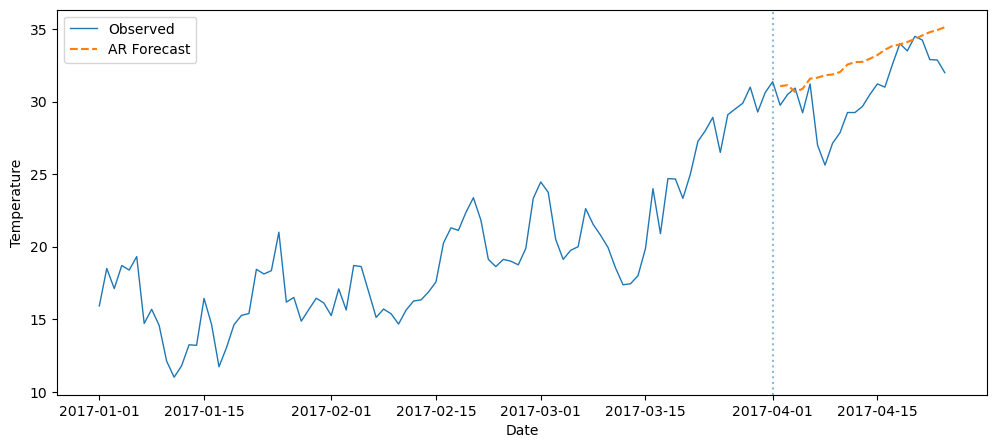

In [54]:
plt.figure(figsize=(12,5))
plt.plot(df['Temperature'],label='Observed',linewidth=1)
plt.plot(forecast_orig, label='AR Forecast', linestyle='--')

plt.axvline(df.index[train_size], alpha=0.5, linestyle=':')   # To visually separate the training and test datasets in a time series plot

plt.xlabel('Date')
plt.ylabel('Temperature')

plt.legend()
plt.show()